In [3]:
# Imports and Configurations
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Statistical Testing
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.stats.multitest import multipletests
from itertools import combinations
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

np.random.seed(42)

# NASDAQ Universe 
TICKERS = [
    'AAPL', 'ADBE', 'ADI', 'ADP', 'ADSK', 'ALGN', 'AMAT', 'AMD', 'AMGN',
    'AMZN', 'ANSS', 'ASML', 'AVGO', 'AZN', 'BIIB', 'BKNG', 'BKR', 'CCEP',
    'CDNS', 'CDW', 'COST', 'CPRT', 'CSGP', 'CSCO', 'CTAS', 'CTSH', 'DLTR',
    'DXCM', 'EA', 'EXC', 'FANG', 'FAST', 'FTNT', 'GILD', 'GOOG', 'GOOGL',
    'HON', 'IDXX', 'ILMN', 'INTU', 'ISRG', 'KDP', 'KLAC', 'LIN', 'LRCX',
    'MAR', 'MCHP', 'MDLZ', 'MELI', 'META', 'MNST', 'MRNA', 'MRVL', 'MSFT',
    'MTCH', 'MU', 'NFLX', 'NVDA', 'ODFL', 'ON', 'ORLY', 'PANW', 'PARA',
    'PAYX', 'PCAR', 'PEP', 'QCOM', 'REGN', 'ROST', 'SBUX', 'SIRI', 'SMCI',
    'SNPS', 'TXN', 'VRSK', 'VRTX', 'WBD', 'WDAY', 'XEL'
]

# Defining Periods (matching Notebook 4)
TRAIN_START = '2014-01-01'
TRAIN_END   = '2017-12-31'
VAL_START   = '2018-01-01'
VAL_END     = '2020-12-31'
TEST_START  = '2021-01-01'
TEST_END    = '2023-12-31'

# Strategy Parameters (matching Notebook 3 and 4)
SHARPE_WINDOW    = 52
ZSCORE_WINDOW    = 52
ENTRY_THRESHOLD  = 2.0
EXIT_THRESHOLD   = 0.5
STOP_LOSS        = 3.5
HIGH_VOL_ENTRY   = 2.5
LOW_VOL_ENTRY    = 1.5
VOL_WINDOW       = 26
VOL_THRESHOLD    = 1.5

# Clustering parameters (same as Notebook 2)
K_VALUES = [2,4,7]

print('Notebook 5: OCP Clustering for Pairs Trading')
print('=' * 55)
print(f'Universe:          {len(TICKERS)} stocks')
print(f'K Values:          {K_VALUES}')
print(f'Sharpe window:     {SHARPE_WINDOW} weeks')
print(f'Training period:   {TRAIN_START} to {TRAIN_END}')
print(f'Validation period: {VAL_START} to {VAL_END}')
print(f'Test period:    {TEST_START} to {TEST_END}')
print('\nAll imports successful.')

Notebook 5: OCP Clustering for Pairs Trading
Universe:          79 stocks
K Values:          [2, 4, 7]
Sharpe window:     52 weeks
Training period:   2014-01-01 to 2017-12-31
Validation period: 2018-01-01 to 2020-12-31
Test period:    2021-01-01 to 2023-12-31

All imports successful.


In [4]:
# Downloading price data
import yfinance as yf

print('Downloading price data for NASDAQ 100 universe...')
print(f'Tickers: {len(TICKERS)} stocks, 2014-2023, weekly Wednesday\n')

raw = yf.download(
    TICKERS, 
    start='2014-01-01',
    end='2024-01-01',
    interval='1wk',
    auto_adjust=True,
    progress=True
)

price_data = raw['Close']
price_data = price_data.resample('W-WED').last()
price_data = price_data.dropna(how='all')
price_data = price_data.ffill().dropna(axis=1)

print(f'\nPrice data shape: {price_data.shape}')
print(f'Date range: {price_data.index[0].date()} to {price_data.index[-1].date()}')
print(f'Tickers retained: {len(price_data.columns)}')

# Computing weekly returns
returns = price_data.pct_change().dropna()

print(f'\nReturns shape: {returns.shape}')

# Computing rolling Sharpe Ratio
print(f'\nComputing rolling {SHARPE_WINDOW}-week Sharpe Ratio...')

def compute_sharpe(returns, window=52):
    """
    Computes rolling annualized Sharpe Ratio for each stock.
    Sharpe = (mean return / std return) * sqrt(52)
    No risk-free rate subtracted - consistent with Notebook 2.
    """
    rolling_mean = returns.rolling(window=window).mean()
    rolling_std  = returns.rolling(window=window).std()
    sharpe       = (rolling_mean / rolling_std) * np.sqrt(52)
    return sharpe

sharpe_data = compute_sharpe(returns, window=SHARPE_WINDOW)
sharpe_data = sharpe_data.dropna(how='all')

# Retaining tickers only present in both price and sharpe data
common_tickers = [t for t in price_data.columns
                  if t in sharpe_data.columns]
price_data     = price_data[common_tickers]
sharpe_data    = sharpe_data[common_tickers]

print(f'Sharpe data shape: {sharpe_data.shape}')
print(f'Date range: {sharpe_data.index[0].date()} to '
      f'{sharpe_data.index[-1].date()}')
print(f'Tickers retained: {len(common_tickers)}')
print(f'\nTicker list: {','.join(common_tickers)}')

Tickers: 79 stocks, 2014-2023, weekly Wednesday



[*                      3%                       ]  2 of 79 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ANSS"}}}
$ANSS: possibly delisted; no timezone found      ]  14 of 79 completed
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PARA"}}}
$PARA: possibly delisted; no timezone found****  ]  76 of 79 completed
[*********************100%***********************]  79 of 79 completed

2 Failed downloads:
['ANSS', 'PARA']: possibly delisted; no timezone found



Price data shape: (522, 76)
Date range: 2014-01-01 to 2023-12-27
Tickers retained: 76

Returns shape: (521, 76)

Computing rolling 52-week Sharpe Ratio...
Sharpe data shape: (470, 76)
Date range: 2014-12-31 to 2023-12-27
Tickers retained: 76

Ticker list: AAPL,ADBE,ADI,ADP,ADSK,ALGN,AMAT,AMD,AMGN,AMZN,ASML,AVGO,AZN,BIIB,BKNG,BKR,CCEP,CDNS,CDW,COST,CPRT,CSCO,CSGP,CTAS,CTSH,DLTR,DXCM,EA,EXC,FANG,FAST,FTNT,GILD,GOOG,GOOGL,HON,IDXX,ILMN,INTU,ISRG,KDP,KLAC,LIN,LRCX,MAR,MCHP,MDLZ,MELI,META,MNST,MRVL,MSFT,MTCH,MU,NFLX,NVDA,ODFL,ON,ORLY,PANW,PAYX,PCAR,PEP,QCOM,REGN,ROST,SBUX,SIRI,SMCI,SNPS,TXN,VRSK,VRTX,WBD,WDAY,XEL


In [3]:
# Optimal Causal Path (OCP) Distance Function
def ocp_distance(x,y):
    """
    Computes the Optimal Causal Path (OCP) distance between two time series.

    Based on Stubinger (2019): "Statistical Arbitrage with Optimal Causal Paths
    on High-Frequency Data of the S&P500."

    The key difference from standard DTW:
    - DTW allows warping in both directions (symmetric)
    - OCP enforces causality - the warping path can only move forward in time
      meaning series x at time t can only be matched to sereies y at time t
      or later, never to time t-1 or earlier.

    This prevents economically meaningless backward-looking matches and ensures
    only genuinely exploitable lead-lag relationships are captured.

    Parameters:
        x: numpy arrays - first time series (e.g. Sharpe ratio series of stock A)
        y: numpy arrays - second time series (e.g. Sharpe ratio series of stock B)

    Returns:
        float: OCP distance between x and y. Lower = more causally similar.
    """
    n = len(x)
    m = len(y)

    # Initializing cost matrix
    D = np.full((n, m), np.inf)

    # Starting point
    D[0,0] = (x[0] - y[0]) ** 2

    # Filling first column: x can only match y[0] moving forward
    # for i in range(1,n):
        # D[i,0] = D[i-1,0] + (x[i] - y[0]) ** 2

    # Filling first row: y can only match x[0] moving forward
    for j in range(1,m):
        D[0,j] = D[0,j-1] + (x[0] - y[j]) ** 2

    # Fill remaining cells with causality constraints
    for i in range(1,n):
        for j in range(1,m):
            # This prevents y at time j from being matched to x at time i
            if j >= i:
                cost   = (x[i] - y[j]) ** 2
                D[i,j] = cost + min(
                    D[i-1, j],
                    D[i, j-1],
                    D[i-1, j-1]
                )

    # Returning normalized distance
    return np.sqrt(D[n-1, m-1]) / (n + m)   

# Verifying OCP function with a simple test
print("Testing OCP distance function...")

# Two identical time series should have distance 0
x_test = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_test = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
d_identical = ocp_distance(x_test, y_test)
print(f'Distance between identical series: {d_identical:.6f} (should be 0.0)')

# Two different series should have positive distance
y_test2 = np.array([5.0, 4.0, 3.0, 2.0, 1.0])
d_different = ocp_distance(x_test, y_test2)
print(f'Distance between opposite series: {d_different:.6f} (should be > 0)')

# OCP should be asymmetric - ocp(x,y) may not be equal to ocp(y,x)
x_lead = np.array([1.0, 3.0, 2.0, 4.0, 3.0, 5.0, 4.0])
y_lag  = np.array([0.0, 0.0, 1.0, 3.0, 2.0, 4.0, 3.0])
d_forward  = ocp_distance(x_lead, y_lag)
d_backward = ocp_distance(y_lag, x_lead)
print(f"OCP(x_lead, y_lag):  {d_forward:.6f}")
print(f"OCP(y_lag, x_lead):  {d_backward:.6f}")
print(f"Asymmetric: {abs(d_forward - d_backward) > 1e-10}")
print(f"x leads y: {d_forward < d_backward}")

print('\nOCP distance function verified.')

Testing OCP distance function...
Distance between identical series: 0.000000 (should be 0.0)
Distance between opposite series: 0.632456 (should be > 0)
OCP(x_lead, y_lag):  0.159719
OCP(y_lag, x_lead):  0.276642
Asymmetric: True
x leads y: True

OCP distance function verified.


In [11]:
import time

def compute_ocp_matrix(sharpe_data):
    """
    Computes the pairwise OCP distance matrix for all stocks.

    For each pair (i,j) computes both ocp(i,j) and ocp(j,i) and
    takes the minimum as the symmetric distance for clustering.

    This improves on Stubinger (2019) who assumes a fixed lead-lag
    direction. Taking the minimum captures the strongest causal
    relationship regardless of direction.

    Returns a symmetric n x n distance matrix.
    """
    tickers = sharpe_data.columns.tolist()
    n       = len(tickers)
    matrix  = np.zeros((n, n))

    total_pairs = n * (n - 1) // 2
    completed   =  0
    
    print(f'Computing OCP distances for {n} stocks...')
    print(f'Total unique pairs: {total_pairs}')

    start_time = time.time()

    for i in range(n):
        for j in range(i + 1, n):
            x = sharpe_data.iloc[:, i].values
            y = sharpe_data.iloc[:, j].values

            # Removing any NaN values
            mask = ~(np.isnan(x) | np.isnan(y))
            x    = x[mask]
            y    = y[mask]

            # Computing OCP in both directions and take minimum 
            d_xy = ocp_distance(x, y)
            d_yx = ocp_distance(y, x)
            d    = min(d_xy, d_yx)

            # Filling both sides of symmetric matrix
            matrix[i, j] = d
            matrix[j, i] = d

            completed += 1
            if completed % 200 == 0 and completed > 0:
                elapsed = time.time() - start_time
                pct     = completed / total_pairs * 100
                eta     = (elapsed / completed) * (total_pairs - completed)
                print(f'  {completed}/{total_pairs} pairs '
                      f' ({pct:.1f}%) - '
                      f'elapsed: {elapsed:.0f}s - '
                      f'ETA: {eta:.0f}s')

    elapsed = time.time() - start_time
    print(f'\nComplete. Total time: {elapsed:.0f} seconds')
    print(f'Distance matrix shape: {matrix.shape}')

    return matrix, tickers   

# Running Computations
print('Starting OCP distance matrix computation...')
print('Note: OCP requires two passes per pair (both directions)')
print('Expected time: 20-60 minutes depending on your machine\n')

ocp_matrix, tickers = compute_ocp_matrix(sharpe_data)

# Saving immediately
np.save('ocp_distance_matrix.npy', ocp_matrix)
print(f'\nDistance matrix saved to ocp_distance_matrix.npy')
print('Do not close the notebook until this save is confirmed.')

# Basic Validation
print(f'\nMatrix Validation:')
print(f'  Shape:                  {ocp_matrix.shape}')
print(f'  Diagonal (should be 0): {np.diag(ocp_matrix).max():.6f}')
print(f'  Min off-diagonal:       {ocp_matrix[ocp_matrix > 0].min():.6f}')
print(f'  Max distance:           {ocp_matrix.max():.6f}')
print(f'  Symmetric:              {np.allclose(ocp_matrix, ocp_matrix.T)}')

Starting OCP distance matrix computation...
Note: OCP requires two passes per pair (both directions)
Expected time: 20-60 minutes depending on your machine

Inside function - n: 76, len(tickers): 76
First 3 tickers: ['AAPL', 'ADBE', 'ADI']
Computing OCP distances for 76 stocks...
Total unique pairs: 2850
Outer loop i=0
Outer loop i=1
Outer loop i=2
  200/2850 pairs  (7.0%) - elapsed: 74s - ETA: 984s
Outer loop i=3
Outer loop i=4
Outer loop i=5
  400/2850 pairs  (14.0%) - elapsed: 147s - ETA: 903s
Outer loop i=6
Outer loop i=7
Outer loop i=8
  600/2850 pairs  (21.1%) - elapsed: 220s - ETA: 825s
Outer loop i=9
Outer loop i=10
Outer loop i=11
  800/2850 pairs  (28.1%) - elapsed: 292s - ETA: 748s
Outer loop i=12
Outer loop i=13
Outer loop i=14
  1000/2850 pairs  (35.1%) - elapsed: 364s - ETA: 673s
Outer loop i=15
Outer loop i=16
Outer loop i=17
Outer loop i=18
  1200/2850 pairs  (42.1%) - elapsed: 436s - ETA: 600s
Outer loop i=19
Outer loop i=20
Outer loop i=21
  1400/2850 pairs  (49.1%) -

Loaded OCP matrix shape: (76, 76)
OCP heirarchical clustering complete.
Linkage matrix shape: (75, 4)

k=2:
 Cluster 1 (32 stocks): AAPL, ADBE, ALGN, AMAT, AMZN, ASML, AVGO, CDNS, CDW, COST, CPRT, CTAS, FTNT, GOOG, GOOGL, IDXX, INTU, ISRG, KLAC, LRCX, MAR, MELI, META, MSFT, NFLX, NVDA, ODFL, ORLY, PANW, PAYX, SMCI, SNPS
 Cluster 2 (44 stocks): ADI, ADP, ADSK, AMD, AMGN, AZN, BIIB, BKNG, BKR, CCEP, CSCO, CSGP, CTSH, DLTR, DXCM, EA, EXC, FANG, FAST, GILD, HON, ILMN, KDP, LIN, MCHP, MDLZ, MNST, MRVL, MTCH, MU, ON, PCAR, PEP, QCOM, REGN, ROST, SBUX, SIRI, TXN, VRSK, VRTX, WBD, WDAY, XEL

k=4:
 Cluster 1 (8 stocks): ADBE, ALGN, AMZN, GOOG, GOOGL, MELI, META, NFLX
 Cluster 2 (24 stocks): AAPL, AMAT, ASML, AVGO, CDNS, CDW, COST, CPRT, CTAS, FTNT, IDXX, INTU, ISRG, KLAC, LRCX, MAR, MSFT, NVDA, ODFL, ORLY, PANW, PAYX, SMCI, SNPS
 Cluster 3 (23 stocks): ADI, AMD, AZN, BKNG, BKR, CCEP, CTSH, FANG, FAST, GILD, LIN, MCHP, MDLZ, MRVL, MU, ON, PCAR, QCOM, REGN, VRSK, VRTX, WBD, WDAY
 Cluster 4 (21 st

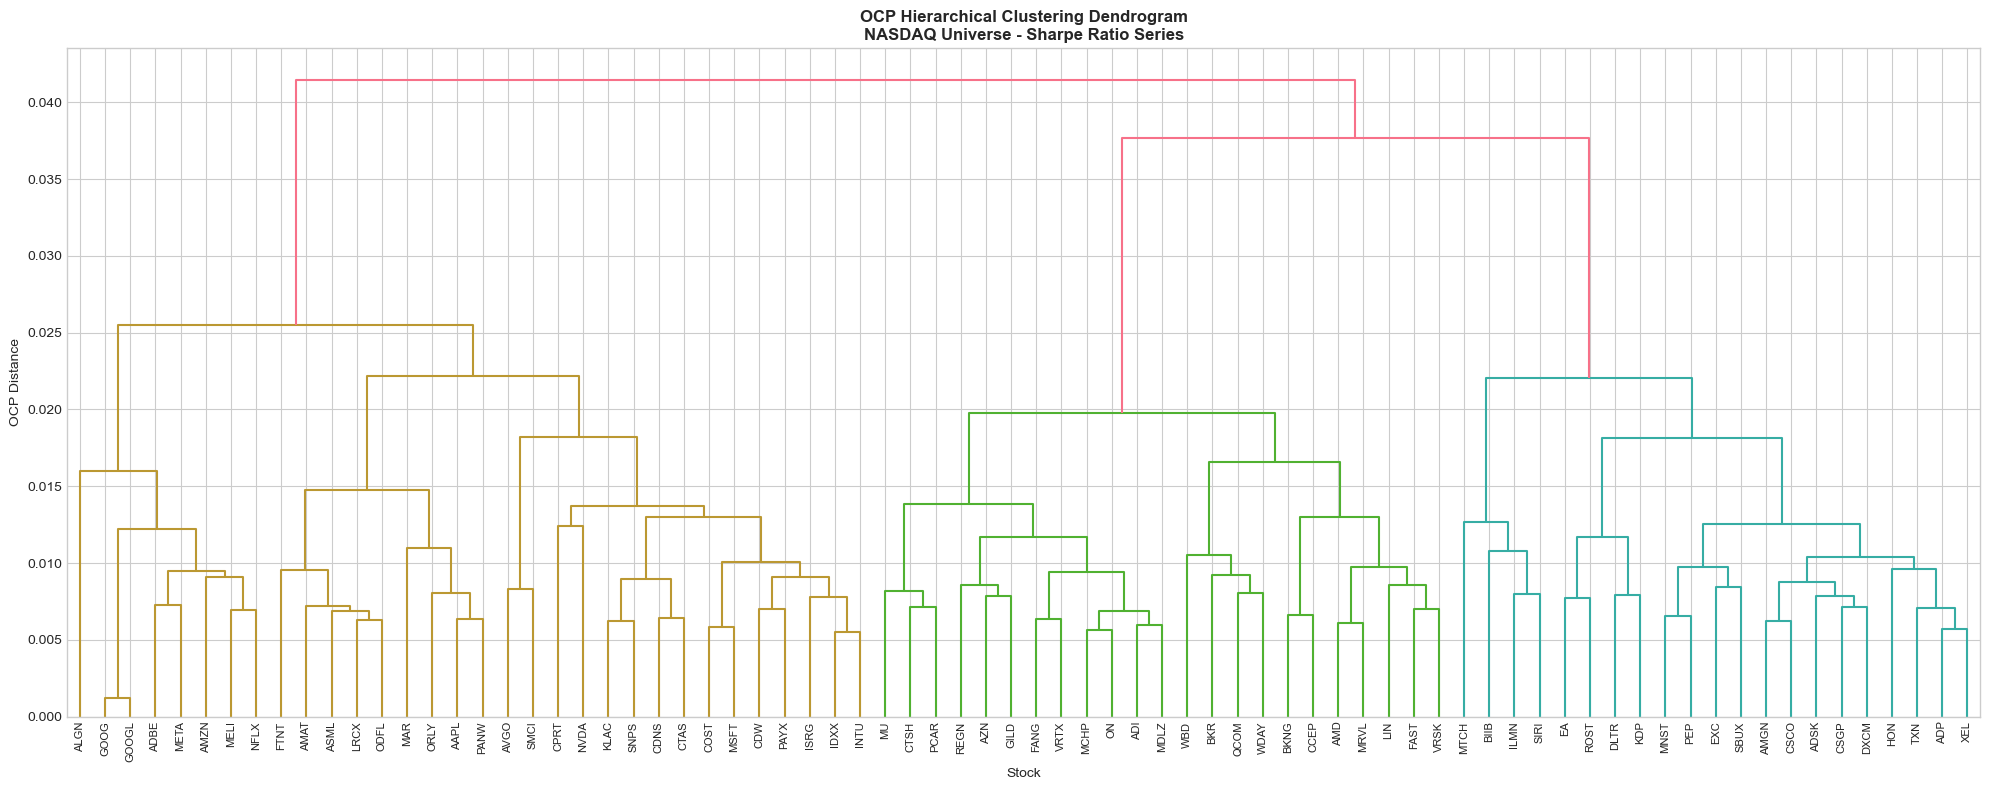


Cluster assignments saved for k=2, k=4, k=7.


In [6]:
ocp_matrix = np.load('ocp_distance_matrix.npy')
tickers = sharpe_data.columns.tolist()
print(f'Loaded OCP matrix shape: {ocp_matrix.shape}')

# Hierarchical clustering with OCP distance matrix

condensed_dist = squareform(ocp_matrix)

ocp_linkage = linkage(condensed_dist, method='ward')

print('OCP heirarchical clustering complete.')
print(f'Linkage matrix shape: {ocp_linkage.shape}')

# Generating cluster assignments for each k value
ocp_clusters = {}

for k in K_VALUES:
    cluster_labels = fcluster(ocp_linkage, k, criterion='maxclust')
    ocp_clusters[k] = pd.DataFrame({
        'Ticker': tickers,
        'Cluster': cluster_labels
    })

    print(f'\nk={k}:')
    for cluster_num in sorted(ocp_clusters[k]['Cluster'].unique()):
        cluster_tickers = ocp_clusters[k][
            ocp_clusters[k]['Cluster'] == cluster_num
        ]['Ticker'].tolist()
        print(f' Cluster {cluster_num} ({len(cluster_tickers)} stocks): '
              f'{', '.join(cluster_tickers)}')  

# Plotting Dendrogram
plt.figure(figsize=(20,8))
dendrogram(ocp_linkage, labels=tickers, leaf_rotation=90, leaf_font_size=8)
plt.title('OCP Hierarchical Clustering Dendrogram\n'
          'NASDAQ Universe - Sharpe Ratio Series',
          fontweight='bold')
plt.xlabel('Stock')
plt.ylabel('OCP Distance')
plt.tight_layout()
plt.savefig('ocp_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

# Saving clustering assignments
for k in K_VALUES:
    ocp_clusters[k].to_csv(f'ocp_cluster_assignments_k{k}.csv',index=False)

print('\nCluster assignments saved for k=2, k=4, k=7.')

In [8]:
# Cluster validity indices for OCP Clustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

print('Computing cluster validity indices for OCP clustering...')
print('(Silhouette, Calinski-Harabasz, Davies-Bouldin)\n')

ocp_cvi_results = []

for k in K_VALUES:
    cluster_labels = ocp_clusters[k]['Cluster'].values

    sil = silhouette_score(ocp_matrix, cluster_labels, metric='precomputed')
    ch  = calinski_harabasz_score(sharpe_data.T.values, cluster_labels)
    db  = davies_bouldin_score(sharpe_data.T.values, cluster_labels)

    ocp_cvi_results.append({
        'k': k,
        'Silhouette': round(sil, 4),
        'Calinski-Harabasz': round(ch, 2),
        'Davies-Bouldin': round(db, 4)
    })

ocp_cvi_df = pd.DataFrame(ocp_cvi_results).set_index('k')

print('OCP Cluster Validity Indices:')
print(ocp_cvi_df.to_string())
print("""
Interpretation guide:
    Silhouette:          higher is better (range -1 to 1)
    Calinski-Harabasz:   higher is better (no fixed range)
    Davies-Bouldin:      lower is better  (range 0 to infinity)
""")

# Compare cluster membership: OCP vs. DTW
# Loading DTW cluster assignments from Notebook 2 for comparison
print('Loading DTW cluster assignments from Notebook 2 for comparison...')

dtw_clusters = {}
for k in K_VALUES:
    try: 
        dtw_clusters[k] = pd.read_csv(f'cluster_assignments_sharpe_k{k}.csv')
        print(f' k={k}: loaded {len(dtw_clusters[k])} ticker assignments')
    except FileNotFoundError:
        print(f' k={k}: file not found, skipping comparison for k')

# Computing cluster agreement using Adjusted Random Index
from sklearn.metrics import adjusted_rand_score

print('\nComparing OCP and DTW cluster membership (Adjusted Rand Index):')
print('(0 = no agreement / random, 1 = perfect agreement)\n')

for k in K_VALUES:
    if k in dtw_clusters:
        # Aligning on common tickers
        merged = pd.merge(
            ocp_clusters[k], dtw_clusters[k],
            on='Ticker', suffixes=('_ocp', '_dtw')
        )

        ari = adjusted_rand_score(
            merged['Cluster_ocp'], merged['Cluster_dtw']
        )

        print(f' k={k}: ARI = {ari:.4f} '
              f'({len(merged)} common tickers)')       

Computing cluster validity indices for OCP clustering...
(Silhouette, Calinski-Harabasz, Davies-Bouldin)

OCP Cluster Validity Indices:
   Silhouette  Calinski-Harabasz  Davies-Bouldin
k                                               
2      0.1230             9.0700          2.7456
4      0.1141             5.5200          2.8810
7      0.0993             3.9000          3.0582

Interpretation guide:
    Silhouette:          higher is better (range -1 to 1)
    Calinski-Harabasz:   higher is better (no fixed range)
    Davies-Bouldin:      lower is better  (range 0 to infinity)

Loading DTW cluster assignments from Notebook 2 for comparison...
 k=2: file not found, skipping comparison for k
 k=4: file not found, skipping comparison for k
 k=7: file not found, skipping comparison for k

Comparing OCP and DTW cluster membership (Adjusted Rand Index):
(0 = no agreement / random, 1 = perfect agreement)



In [ ]:
# Building cluster map from OCP assignments
ocp_cluster_map = {}

for k in K_VALUES:
    ocp_cluster_map[k] = {}
    for cluster_num in sorted(ocp_clusters[k]['Cluster'].unique()):
        tickers_in_cluster = ocp_clusters[k][
            ocp_clusters[k]['Cluster'] == cluster_num
        ]['Ticker'].tolist()
        ocp_cluster_map[k][cluster_num] = tickers_in_cluster

print("OCP cluster map built.")
print(f'k values: {list(ocp_cluster_map.keys())}')